In [2]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import cooler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import custom libraries
import sys
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicvisutils import hic_vis, hic_vis_region
from hicdatautils import import_cool, get_chrs, standardize_coolers, standardize_coolers_ref

In [ ]:
# Import files
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data'
arc_pair = f'{data_dir}/sc_data/arc_pair_570552.cool'
clp = f'{data_dir}/taghic/GSE152918_CLP.mcool'
hpmbc = f'{data_dir}/hPBM/4DNFI4RPZR34.mcool'
hct119= f'{data_dir}/HCT119/4DNFIQF4HNZ2.mcool'

In [16]:
# Cooler import and data check
clr = import_cool(hpmbc, 1_000_000)
clr2 = import_cool(arc_pair)
clr3 = import_cool(hct119, 1_000_000)

names, lengths = get_chrs(clr)
names2, lengths2 = get_chrs(clr2)
names3, lengths3 = get_chrs(clr3)
print(lengths)
print(lengths2)

[np.int32(248956422), np.int32(242193529), np.int32(198295559), np.int32(190214555), np.int32(181538259), np.int32(170805979), np.int32(159345973), np.int32(145138636), np.int32(138394717), np.int32(133797422), np.int32(135086622), np.int32(133275309), np.int32(114364328), np.int32(107043718), np.int32(101991189), np.int32(90338345), np.int32(83257441), np.int32(80373285), np.int32(58617616), np.int32(64444167), np.int32(46709983), np.int32(50818468), np.int32(156040895), np.int32(57227415)]
[np.int32(249000000), np.int32(243000000), np.int32(199000000), np.int32(191000000), np.int32(182000000), np.int32(171000000), np.int32(160000000), np.int32(146000000), np.int32(139000000), np.int32(134000000), np.int32(136000000), np.int32(134000000), np.int32(115000000), np.int32(108000000), np.int32(102000000), np.int32(91000000), np.int32(84000000), np.int32(81000000), np.int32(59000000), np.int32(65000000), np.int32(47000000), np.int32(51000000), np.int32(157000000)]


In [17]:
# Testing standardization
outdir = f'{data_dir}/sc_compare_test'
st_clr, st_clr2 = standardize_coolers(clr, clr2, f"{outdir}/hpmbc_comp.cool", f"{outdir}/arc_comp.cool")

<class 'numpy.float64'>


In [21]:
# Testing reference standardization
st_ref_clr2 = standardize_coolers_ref(clr2, st_clr, f'{outdir}/arc_comp_ref.cool')

In [ ]:
# Inspecting standardized data
pixels = clr2.pixels()[:]
st_pixels = st_clr2.pixels()[:]
check1 = pixels[pixels['count']==0][pixels["bin2_id"]!=3043]
check2 = st_pixels[st_pixels['count']==0]

Raw pixels:
        bin1_id  bin2_id  count
216752     2924     3041    0.0
217307     2929     3041    0.0
217628     2932     3041    0.0
217940     2935     3041    0.0
218042     2936     3041    0.0
218243     2938     3041    0.0
218342     2939     3041    0.0
218537     2941     3041    0.0
218633     2942     3041    0.0
218728     2943     3041    0.0
219623     2959     3041    0.0
219707     2960     3041    0.0
220915     2976     3041    0.0
220916     2976     3042    0.0
220982     2977     3041    0.0
220983     2977     3042    0.0
221048     2978     3041    0.0
221049     2978     3042    0.0
221113     2979     3041    0.0
221114     2979     3042    0.0
ST pixels:
        bin1_id  bin2_id  count
213939     2902     3019    0.0
214489     2907     3019    0.0
214807     2910     3019    0.0
215116     2913     3019    0.0
215217     2914     3019    0.0
215416     2916     3019    0.0
215514     2917     3019    0.0
215707     2919     3019    0.0
215802     2920  

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_59676/4229276807.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  check1 = pixels[pixels['count']==0][pixels["bin2_id"]!=3043]
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_59676/4229276807.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(pixels[pixels['count']==0][pixels["bin2_id"]!=3043].tail(20))


{'sum': np.float64(51.098393),
 'max': np.float64(0.064043),
 'min': np.float64(0.0)}

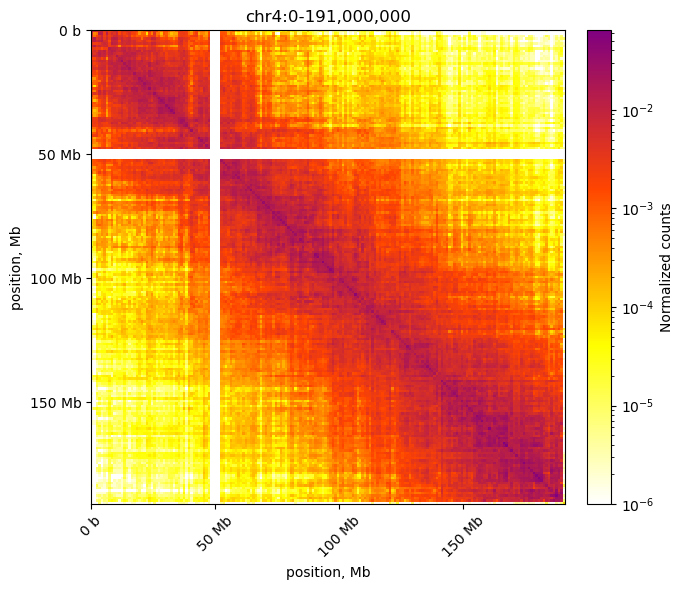

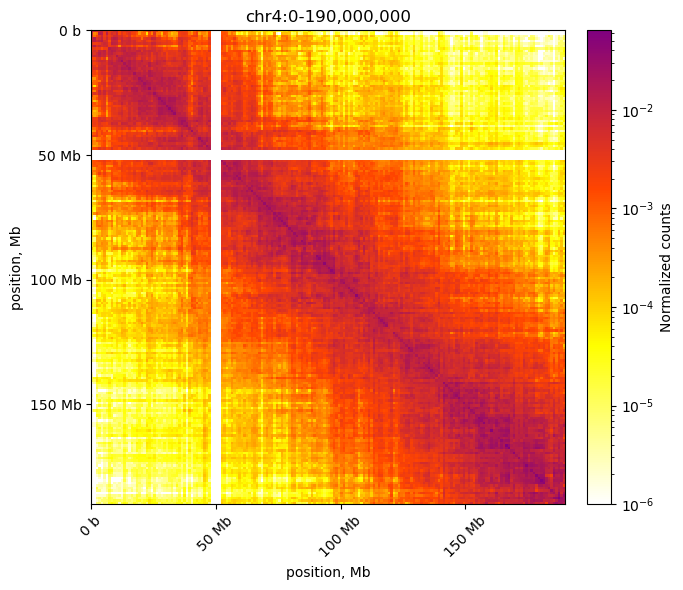

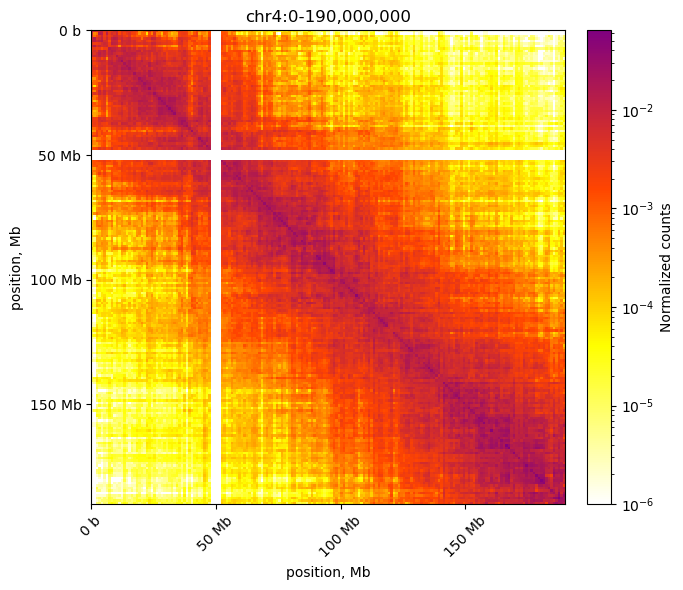

In [22]:
# Chr1 arc
hic_vis_region(clr2, data_type="Normalized", chrom="chr4", cmap="higlass")

# Chr1 arc st
hic_vis_region(st_clr2, data_type="Normalized", chrom="chr4", cmap="higlass")

# Chr1 arc st ref
hic_vis_region(st_ref_clr2, data_type="Normalized", chrom="chr4", cmap="higlass")

{'sum': np.float64(11203487.0),
 'max': np.float64(53419.0),
 'min': np.float64(1.0)}

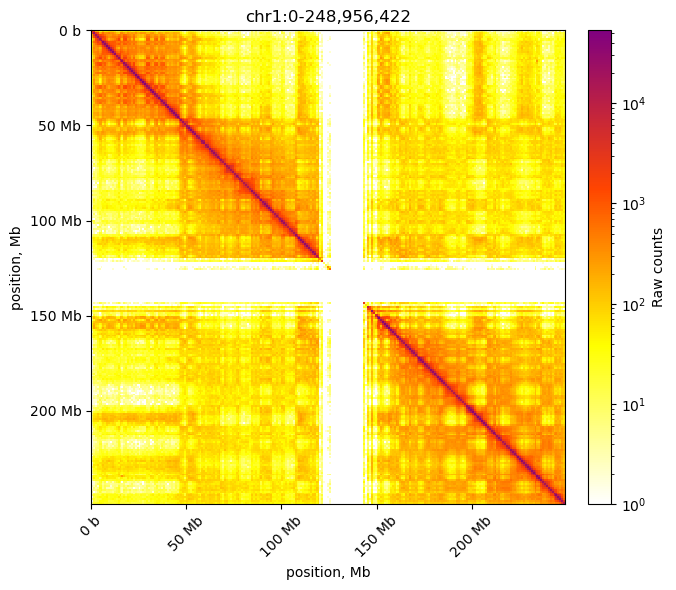

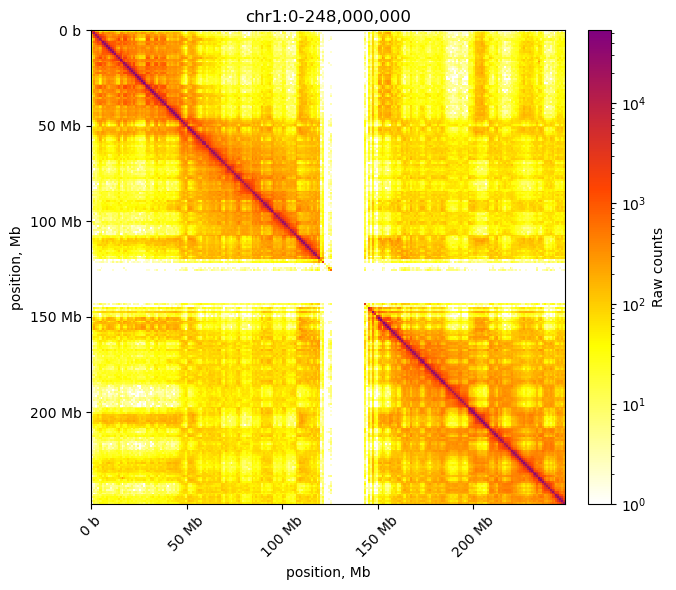

In [ ]:
# Chr1 hpmbc
hic_vis_region(clr, data_type="Raw", chrom="chr1", cmap="higlass")

# Chr1 arc st
hic_vis_region(st_clr, data_type="Raw", chrom="chr1", cmap="higlass")

{'sum': np.float64(95.407228),
 'max': np.float64(0.13276),
 'min': np.float64(0.0)}

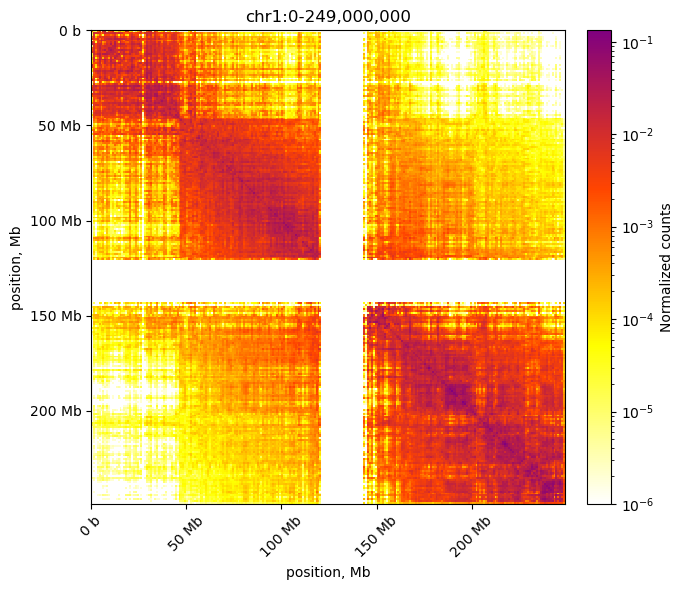

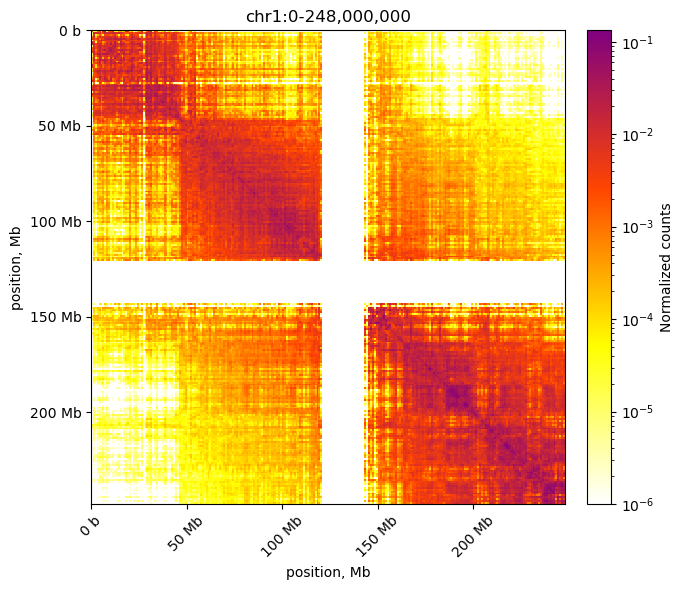

In [145]:
# Chr1 arc
hic_vis_region(clr2, data_type="Normalized", chrom="chr1", cmap="higlass")

# Chr1 arc st
hic_vis_region(st_clr2, data_type="Normalized", chrom="chr1", cmap="higlass")